In [3]:
# Set relative directories
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

In [5]:
import os
os.chdir('C:/Users/Tom/Desktop/east_africa_conflict_analysis/')

In [6]:
# Library imports
from src.data_cleaning import clean_data_pipeline
from src.feature_engineering import feature_engineering_pipeline
from src.modelling import run_gwr_pipeline
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
import numpy as np
import statsmodels.api as sm

In [7]:
# Define countries and OSM features
countries = {
    'eth': {'name': 'Ethiopia', 'code': 'ETH'},
    'ken': {'name': 'Kenya', 'code': 'KEN'},
    'ssd': {'name': 'South Sudan', 'code': 'SSD'},
    'uga': {'name': 'Uganda', 'code': 'UGA'}
}

osm_features = {
    'police': {'amenity': ['police']},
    'hospitals': {'amenity': ['hospital', 'clinic']},
    'schools': {'amenity': ['school', 'university', 'college']}
}

country_keys = list(countries.keys())
feature_keys = list(osm_features.keys())

In [8]:
# Load data
data = clean_data_pipeline(countries, osm_features)

Starting data cleaning pipeline...
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\eth_police.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\eth_hospitals.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\eth_schools.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_police.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_hospitals.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_schools.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ssd_police.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ssd_hospitals.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ssd_schools.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\uga_police.parquet
Using existing C:\Users\Tom\Desktop\east_africa_confl

In [10]:
def prepare_country_features(
    data,
    country_key,
    feature_keys,
    unit_id_col="GID_2"
):
    """
    Runs the feature_engineering_pipeline for a single country
    and returns the prepared GeoDataFrame.
    """
    data = feature_engineering_pipeline(
        data=data,
        country_key=country_key,
        feature_keys=feature_keys,
        unit_id_col=unit_id_col
    )
    
    gdf = data[country_key]["features"].copy()
    return gdf

In [11]:
# Feature engineering for each country
for c in country_keys:
    print(f"\n=== Preparing features for {c.upper()} ===")
    gdf = prepare_country_features(
        data=data,
        country_key=c,
        feature_keys=feature_keys,
        unit_id_col="GID_2"
    )
    globals()[f"{c}_gdf"] = gdf


=== Preparing features for ETH ===
Starting feature engineering pipeline for: eth
  - Spatially joining ACLED events to admin units...
  - Spatially joining police to admin units...
  - Spatially joining hospitals to admin units...
  - Spatially joining schools to admin units...
  -> Aggregation complete: conflict_count + feature counts added.
Adding population from raster to admin units...
  - Population raster CRS: EPSG:32637
  - Running zonal statistics (sum of population per unit). This may take a moment...
  -> Population added to features (NaN for zero-pop units).
Creating rates and densities...
  -> Rates & log-transforms created for all feature counts.
Feature engineering pipeline complete.

=== Preparing features for KEN ===
Starting feature engineering pipeline for: ken
  - Spatially joining ACLED events to admin units...
  - Spatially joining police to admin units...
  - Spatially joining hospitals to admin units...
  - Spatially joining schools to admin units...
  -> Aggre

In [12]:
def run_country_gwr(
    gdf,
    country_key,
    y_var,
    x_vars
):
    """
    Runs GWR on an already-prepared GeoDataFrame.
    Assumes all variables and CRS are ready.
    """

    # 1. Check y_var and x_vars exist
    missing = [col for col in [y_var] + x_vars if col not in gdf.columns]
    if missing:
        raise ValueError(f"Missing required columns in gdf: {missing}")

    # 2. Drop NA
    gdf = gdf.dropna(subset=[y_var] + x_vars).copy()

    print(f"\n===== Running GWR for {country_key.upper()} =====")
    print(f"Dependent variable: {y_var}")
    print(f"Predictors: {x_vars}")
    print(f"Remaining observations: {len(gdf)}")

    # 3. Safe bandwidth bounds
    n = len(gdf)
    if n < 20:
        print(f"⚠️ WARNING: Only {n} observations. GWR may be unstable.")

    bw_min = max((len(x_vars) + 1) * 5, 10)
    bw_max = max(int(n * 0.8), bw_min + 1)

    print(f"Using bandwidth bounds: bw_min={bw_min}, bw_max={bw_max}")

    # 4. Run GWR pipeline
    gdf_gwr, gwr_results, bw = run_gwr_pipeline(
        gdf,
        y_var=y_var,
        x_vars=x_vars,
        standardize=True,
        kernel='gaussian',
        auto_select_bw=True,
        bw_min=bw_min,
        bw_max=bw_max
    )

    # 5. Print summary
    print(f"\nSelected bandwidth: {bw}")
    print(gwr_results.summary())

    return gdf_gwr, gwr_results, bw


In [13]:
# Run the GWR for each country
for c in country_keys:
    print(f"\n=== Running GWR for {c.upper()} ===")
    gdf = globals()[f"{c}_gdf"]

    gdf_gwr, gwr_results, bw = run_country_gwr(
        gdf=gdf,
        country_key=c,
        y_var="log_conflict_rate",
        x_vars=["log_police_density", "log_hospitals_density", "log_schools_density"]  # adjust as needed
    )

    globals()[f"gdf_gwr_{c}"] = gdf_gwr
    globals()[f"gwr_results_{c}"] = gwr_results
    globals()[f"bw_{c}"] = bw
    
    print(f"gdf_gwr_{c}, gwr_results_{c}, bw_{c} created.")


=== Running GWR for ETH ===

===== Running GWR for ETH =====
Dependent variable: log_conflict_rate
Predictors: ['log_police_density', 'log_hospitals_density', 'log_schools_density']
Remaining observations: 79
Using bandwidth bounds: bw_min=20, bw_max=63
[modeling] Running baseline OLS for comparison...
[modeling] Running OLS: log_conflict_rate ~ log_police_density + log_hospitals_density + log_schools_density
[modeling] OLS complete.
[modeling] OLS R-squared: 0.0865
[modeling] Selecting bandwidth (this may take a moment)...
[modeling] Selected bandwidth: 61.0
[modeling] Fitting GWR model...
[modeling] GWR fit complete.

Selected bandwidth: 61.0
Model type                                                         Gaussian
Number of observations:                                                  79
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of

In [14]:
def plot_gwr_coefficient(coef_col, gdf_gwr_eth, gdf_gwr_ssd, gdf_gwr_ken, gdf_gwr_uga):
    """
    Plot GWR coefficient map for all countries.
    
    Parameters:
    -----------
    coef_col : str
        Column name of the coefficient to plot
    gdf_gwr_eth, gdf_gwr_ssd, gdf_gwr_ken, gdf_gwr_uga : GeoDataFrame
        GeoDataFrames for each country
    """
    # --- 2. Merge into one GeoDataFrame ---
    gdf_all = pd.concat(
        [gdf_gwr_eth, gdf_gwr_ssd, gdf_gwr_ken, gdf_gwr_uga],
        ignore_index=True
    )
    gdf_all = gpd.GeoDataFrame(gdf_all, geometry="geometry", crs=gdf_gwr_ken.crs)

    # --- 3. Compute symmetric color bounds ---
    min_val = gdf_all[coef_col].min()
    max_val = gdf_all[coef_col].max()
    max_abs = max(abs(min_val), abs(max_val))

    # --- 4. Create country outlines (only one polygon per country) ---
    # We dissolve by 'country' to merge all admin units per country
    country_outlines = gdf_all.dissolve(by="COUNTRY", as_index=False)

    # --- 5. Plot the coefficient map ---
    fig, ax = plt.subplots(figsize=(10, 12))

    gdf_all.plot(
        column=coef_col,
        cmap="coolwarm",
        vmin=-max_abs,
        vmax=max_abs,
        legend=True,
        ax=ax,
        legend_kwds={
            'shrink': 0.5,  # Makes colorbar 50% of default size
            'aspect': 15,   # Makes it thinner (higher = thinner)
            'pad': 0.02#,    # Distance from plot
           # 'label': ''     # Optional: remove or customize label
        }    
    )
    #ax.set_title("Local GWR Coefficient of Hospitals on Conflict (All Countries)")
    ax.set_axis_off()

    # --- 6. Overlay country borders (thicker line) ---
    country_outlines.boundary.plot(ax=ax, linewidth=1, edgecolor="black")

    # --- 7. Add country labels at centroid ---
    for _, row in country_outlines.iterrows():
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["COUNTRY"],
            horizontalalignment="center",
            fontsize=8,
            fontweight="bold",
            color="black"
            #bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)
        )

    # --- 8. Add scale bar (ADD THIS SECTION) ---
    scalebar = ScaleBar(
        dx=1,  # 1 unit in your CRS (will be meters if using metric projection)
        units="m",  # Display in kilometers
        length_fraction=0.15,  # Shorter bar (15% of plot width)
        height_fraction=0.01,  # Thinner bar (1% of plot height)
        location='lower left',
        box_alpha=0,  # Transparent background
        font_properties={'size': 8}  # Smaller font
    )
    ax.add_artist(scalebar)

    # --- 9. Add north arrow ---
    # Get the plot limits to position the arrow
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    # Position in upper right (adjust these values as needed)
    arrow_x = x_min + (x_max - x_min) * 0.08  # 8% from right edge
    arrow_y = y_max - (y_max - y_min) * 0.08  # 8% from top edge
    arrow_length = (y_max - y_min) * 0.04  # Arrow length as 4% of plot height

    # Draw the arrow
    ax.annotate('N', xy=(arrow_x, arrow_y), xytext=(arrow_x, arrow_y - arrow_length),
                arrowprops=dict(facecolor='black', width=3, headwidth=8, headlength=8),
                ha='center', va='bottom', fontsize=6, fontweight='bold')

    plt.show()

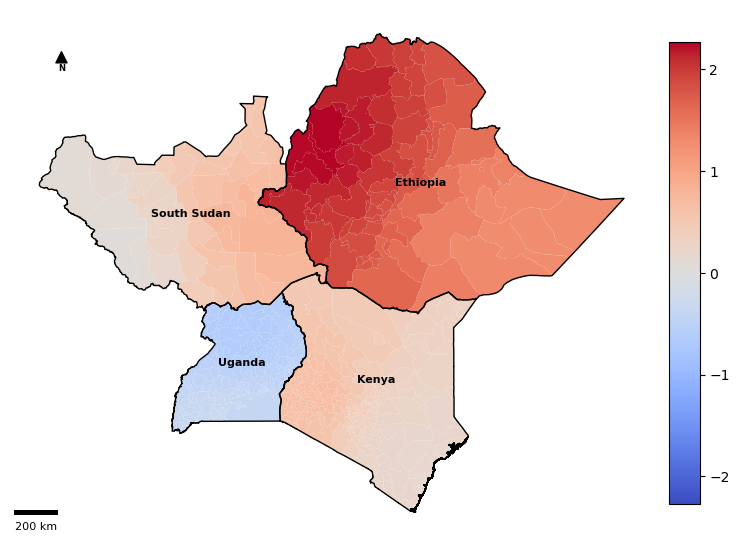

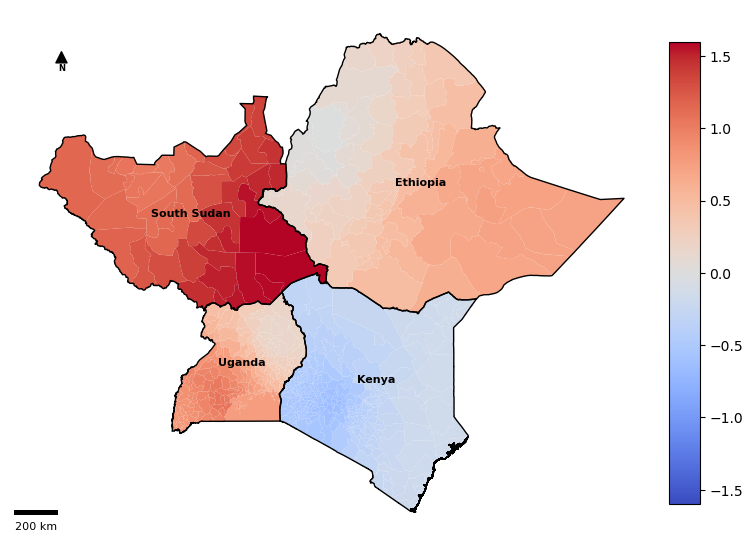

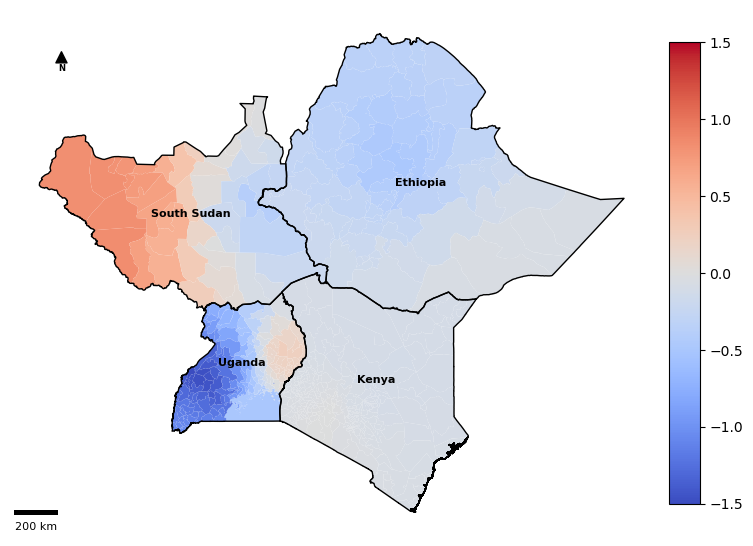

In [15]:
# Usage: Loop through multiple coefficients
coef_list = [
    "gwr_log_police_density_coef",
    "gwr_log_hospitals_density_coef",
    "gwr_log_schools_density_coef"
]

for coef in coef_list:
    plot_gwr_coefficient(coef, gdf_gwr_eth, gdf_gwr_ssd, gdf_gwr_ken, gdf_gwr_uga)

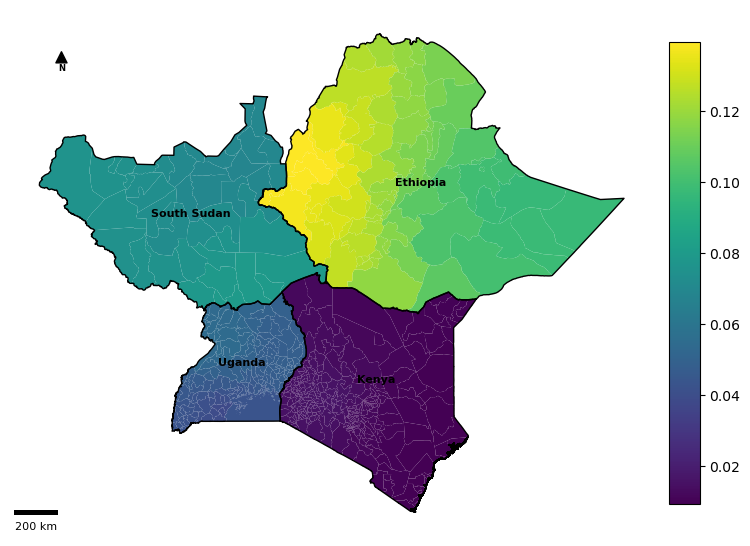

In [16]:
def plot_gwr_r2(gdf_gwr_eth, gdf_gwr_ssd, gdf_gwr_ken, gdf_gwr_uga):
    """
    Plot GWR Local R² map for all countries.
    
    Parameters:
    -----------
    gdf_gwr_eth, gdf_gwr_ssd, gdf_gwr_ken, gdf_gwr_uga : GeoDataFrame
        GeoDataFrames for each country
    """
    # --- 2. Merge into one GeoDataFrame ---
    gdf_all = pd.concat(
        [gdf_gwr_eth, gdf_gwr_ssd, gdf_gwr_ken, gdf_gwr_uga],
        ignore_index=True
    )
    gdf_all = gpd.GeoDataFrame(gdf_all, geometry="geometry", crs=gdf_gwr_ken.crs)

    # --- 3. Get R² bounds (no need for symmetric bounds) ---
    min_val = gdf_all['gwr_local_R2'].min()
    max_val = gdf_all['gwr_local_R2'].max()

    # --- 4. Create country outlines (only one polygon per country) ---
    country_outlines = gdf_all.dissolve(by="COUNTRY", as_index=False)

    # --- 5. Plot the R² map ---
    fig, ax = plt.subplots(figsize=(10, 12))

    gdf_all.plot(
        column='gwr_local_R2',
        cmap="viridis",
        vmin=min_val,
        vmax=max_val,
        legend=True,
        ax=ax,
        legend_kwds={
            'shrink': 0.5,
            'aspect': 15,
            'pad': 0.02
        }    
    )
    #ax.set_title("Local R² of GWR Model (All Countries)")
    ax.set_axis_off()

    # --- 6. Overlay country borders (thicker line) ---
    country_outlines.boundary.plot(ax=ax, linewidth=1, edgecolor="black")

    # --- 7. Add country labels at centroid ---
    for _, row in country_outlines.iterrows():
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["COUNTRY"],
            horizontalalignment="center",
            fontsize=8,
            fontweight="bold",
            color="black"
        )

    # --- 8. Add scale bar ---
    scalebar = ScaleBar(
        dx=1,
        units="m",
        length_fraction=0.15,
        height_fraction=0.01,
        location='lower left',
        box_alpha=0,
        font_properties={'size': 8}
    )
    ax.add_artist(scalebar)

    # --- 9. Add north arrow ---
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    arrow_x = x_min + (x_max - x_min) * 0.08
    arrow_y = y_max - (y_max - y_min) * 0.08
    arrow_length = (y_max - y_min) * 0.04

    ax.annotate('N', xy=(arrow_x, arrow_y), xytext=(arrow_x, arrow_y - arrow_length),
                arrowprops=dict(facecolor='black', width=3, headwidth=8, headlength=8),
                ha='center', va='bottom', fontsize=6, fontweight='bold')

    plt.show()


# Usage:
plot_gwr_r2(gdf_gwr_eth, gdf_gwr_ssd, gdf_gwr_ken, gdf_gwr_uga)

In [17]:
def compare_aic_ols_gwr(gdf, y_var, x_vars, gwr_results):
    """
    Compares OLS AIC/AICc with GWR AICc for a given set of predictors.
    
    Parameters:
        gdf (GeoDataFrame): Contains the variables
        y_var (str): Name of dependent variable
        x_vars (list[str]): Predictor columns
        gwr_results (mgwr.results.GWRResults): Fitted GWR results
    
    Returns:
        pd.DataFrame: Table with OLS AIC, OLS AICc, GWR AICc, and difference
    """
    
    # 1. Extract variables
    y = gdf[y_var]
    X = gdf[x_vars]
    
    # 2. Add constant
    X_const = sm.add_constant(X)
    
    # 3. Fit OLS
    ols_model = sm.OLS(y, X_const).fit()
    
    # 4. OLS AIC
    ols_aic = ols_model.aic
    n = len(y)
    k = len(ols_model.params)  # params incl intercept
    
    # 5. OLS AICc manually
    ols_aicc = ols_aic + (2 * k * (k + 1)) / (n - k - 1)
    
    # 6. GWR AICc
    gwr_aicc = gwr_results.aicc
    
    # 7. Difference
    diff = ols_aicc - gwr_aicc
    
    # 8. Build a nice summary DataFrame
    summary = pd.DataFrame({
        "Predictors": [", ".join(x_vars)],
        "OLS AIC": [ols_aic],
        "OLS AICc": [ols_aicc],
        "GWR AICc": [gwr_aicc],
        "Difference (OLS - GWR)": [diff]
    })
    
    return summary

In [18]:
summary_ken = compare_aic_ols_gwr(gdf_gwr_ken, "log_conflict_rate",
                                  ["log_police_density", "log_hospitals_density", "log_schools_density"],
                                  gwr_results_ken)

summary_eth = compare_aic_ols_gwr(gdf_gwr_eth, "log_conflict_rate",
                                  ["log_police_density", "log_hospitals_density", "log_schools_density"],
                                  gwr_results_eth)

summary_ssd = compare_aic_ols_gwr(gdf_gwr_ssd, "log_conflict_rate",
                                  ["log_police_density", "log_hospitals_density", "log_schools_density"],
                                  gwr_results_ssd)

summary_uga = compare_aic_ols_gwr(gdf_gwr_uga, "log_conflict_rate",
                                  ["log_police_density", "log_hospitals_density", "log_schools_density"],
                                  gwr_results_uga)
summary_all = pd.concat([
    summary_ken.assign(Country="Kenya"),
    summary_eth.assign(Country="Ethiopia"),
    summary_ssd.assign(Country="South Sudan"),
    summary_uga.assign(Country="Uganda")
], ignore_index=True)[["Country", "Predictors", "OLS AIC", "OLS AICc", "GWR AICc", "Difference (OLS - GWR)"]]

summary_all


,Country,Predictors,OLS AIC,OLS AICc,GWR AICc,Difference (OLS - GWR)
0,Kenya,"log_police_density, log_hospitals_density, log...",2003.430347,2003.565940,2005.922577,-2.356637
1,Ethiopia,"log_police_density, log_hospitals_density, log...",515.245215,515.785756,518.423880,-2.638125
2,South Sudan,"log_police_density, log_hospitals_density, log...",321.782983,322.782983,327.110626,-4.327643
3,Uganda,"log_police_density, log_hospitals_density, log...",1107.016448,1107.264896,1107.243795,0.021100
